# Predicción de Calidad del Aire
**Aprendizaje Automático — Junio 2026**
Rebecca Castillo

Universidad Autónoma del Estado de Morelos

---

**Dataset:** Global Air Quality & Deforestation (Kaggle, Apache 2.0)
**Registros:** 35,000 | **Variables:** 15 | **Periodo:** 2014–2023 | **Ciudades:** 225 en 45 países

---
**Objetivos de este avance:**
1. Análisis estadístico descriptivo.
2. Análisis de correlación (todas las variables).
3. Preprocesamiento robusto (Pipelines).
4. Entrenamiento y evaluación en train y test con **todas las variables** — Regresión Lineal, Random Forest y SVR.
5. Discusión de *data leakage* a partir de la matriz de correlación.
6. Entrenamiento y evaluación en train y test **sin las variables con leakage** — los mismos tres modelos.
7. Comparación final e interpretación de resultados.

## 1. Carga de datos y exploración inicial

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

# carga de datos
df = pd.read_csv('/content/drive/MyDrive/global_air_quality_deforestation_dataset.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head(3)

Dimensiones del dataset: (35000, 15)


,Country,City,Year,AQI,PM2.5,PM10,Deforestation_Rate_%,Afforestation_Rate_%,Vehicles_Increase_%,Industries_Increase_%,Env_Budget_Million_USD,Population_Density_Per_SqKm,CO2_Emissions_MT,Green_Space_Ratio_%,Avg_Life_Expectancy_Index
0,Argentina,Buenos Aires,2014,144.02,95.38,124.16,3.93,2.32,11.03,5.13,68.30,7612.92,196.42,35.41,75.54
1,Argentina,Buenos Aires,2014,161.81,73.35,123.64,3.54,1.85,4.50,7.30,143.51,10983.91,174.43,31.03,74.50
2,Argentina,Buenos Aires,2014,133.11,55.49,128.95,1.94,0.39,11.50,8.29,246.25,3442.93,214.09,35.80,76.62


In [3]:
print("--- Información General y Nulos ---")
display(df.info())

--- Información General y Nulos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      35000 non-null  object 
 1   City                         35000 non-null  object 
 2   Year                         35000 non-null  int64  
 3   AQI                          35000 non-null  float64
 4   PM2.5                        35000 non-null  float64
 5   PM10                         35000 non-null  float64
 6   Deforestation_Rate_%         35000 non-null  float64
 7   Afforestation_Rate_%         35000 non-null  float64
 8   Vehicles_Increase_%          35000 non-null  float64
 9   Industries_Increase_%        35000 non-null  float64
 10  Env_Budget_Million_USD       35000 non-null  float64
 11  Population_Density_Per_SqKm  35000 non-null  float64
 12  CO2_Emissions_MT             35000 non

None

In [4]:
print("\nEstadísticas Descriptivas:")
display(df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std']))


Estadísticas Descriptivas:


,count,mean,std,min,25%,50%,75%,max
Year,35000.000000,2018.498914,2.861409,2014.000000,2016.000000,2018.000000,2021.000000,2023.000000
AQI,35000.000000,133.165543,86.385255,15.000000,66.607500,122.235000,179.392500,438.200000
PM2.5,35000.000000,73.190470,49.488236,6.000000,35.647500,65.500000,100.002500,268.370000
PM10,35000.000000,119.846406,79.927673,10.500000,58.892500,107.970000,163.590000,443.020000
Deforestation_Rate_%,35000.000000,2.402560,1.635043,0.050000,0.920000,2.240000,3.670000,7.000000
Afforestation_Rate_%,35000.000000,1.780373,1.190500,0.100000,0.820000,1.480000,2.540000,5.000000
Vehicles_Increase_%,35000.000000,9.248048,5.683271,1.000000,4.920000,7.770000,12.500000,25.000000
Industries_Increase_%,35000.000000,6.468521,4.014841,0.500000,3.500000,5.600000,8.750000,18.000000
Env_Budget_Million_USD,35000.000000,326.663760,299.353821,10.000000,109.520000,222.220000,390.345000,1199.980000
Population_Density_Per_SqKm,35000.000000,9216.702391,6568.983425,200.730000,4073.935000,8175.560000,12091.130000,29998.320000


## 2. Análisis de correlación

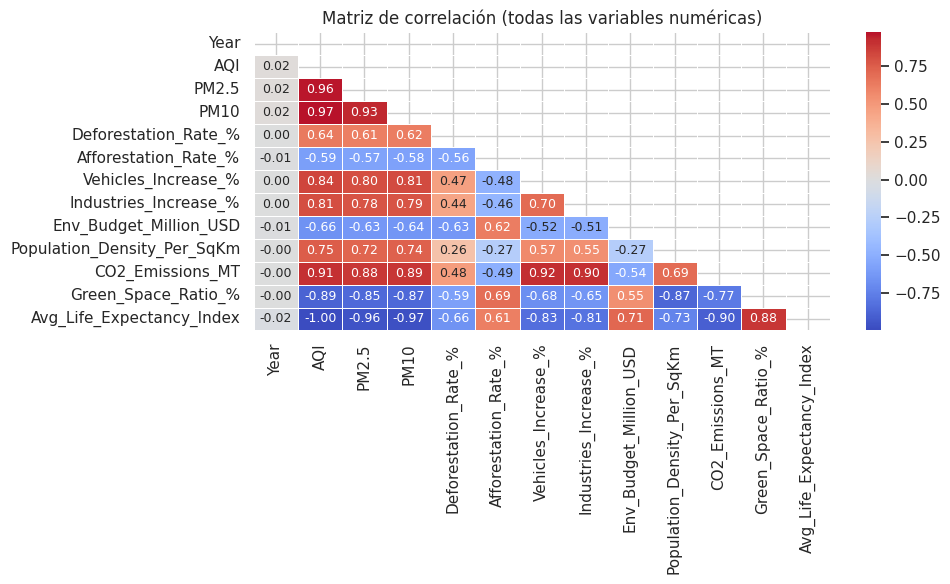

Top 5 variables con mayor correlación absoluta con el AQI:
Avg_Life_Expectancy_Index    0.997333
PM10                         0.973416
PM2.5                        0.960867
CO2_Emissions_MT             0.910840
Green_Space_Ratio_%          0.889393
Name: AQI, dtype: float64


In [5]:
# ver la correlación para ver qué variables influyen más en el AQI
numericas = df.select_dtypes(include=[np.number])
corr = numericas.corr()

fig, ax = plt.subplots(figsize=(10, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9}
)
ax.set_title('Matriz de correlación (todas las variables numéricas)', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 5 variables con mayor correlación absoluta con el AQI:")
print(corr['AQI'].drop('AQI').abs().nlargest(5))

---
## 3. Bloque 1 — Modelos con todas las variables

Se incluyen **todas las variables numéricas y categóricas disponibles** como predictores.
La variable objetivo es `AQI`. Se eliminan únicamente `City` y `Country` del pipeline
categórico por su alta cardinalidad (225 ciudades, 45 países), ya que un OneHotEncoder
sobre estas columnas generaría demasiadas variables dummy y no aporta valor predictivo
adicional frente a las variables ambientales ya disponibles.

Se entrenan tres modelos: **Regresión Lineal**, **Random Forest** y **SVR (Support Vector
Regression)**, evaluando cada uno en train y test.

### 3.1 Separación de variables y partición train/test

In [6]:
from sklearn.model_selection import train_test_split

target = 'AQI'

# todas las variables como features
X_full = df.drop(columns=[target])
y_full = df[target]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

print(f'Set de entrenamiento: {X_train_full.shape[0]} registros')
print(f'Set de prueba:        {X_test_full.shape[0]} registros')

Set de entrenamiento: 28000 registros
Set de prueba:        7000 registros


### 3.2 Pipeline de preprocesamiento

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def construir_preprocesador(X_train):
    cols_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cols_cat = [c for c in X_train.select_dtypes(include=['object']).columns.tolist()
                if c not in ['City', 'Country']]

    preprocesador = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), cols_num),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]), cols_cat)
        ],
        remainder='drop'
    )
    return preprocesador

preprocesador_full = construir_preprocesador(X_train_full)
print("Pipeline de preprocesamiento (Bloque 1: todas las variables) construido")

Pipeline de preprocesamiento (Bloque 1: todas las variables) construido


### 3.3 Función de evaluación

Para no repetir el mismo bloque de métricas tres veces, se define una función que entrena,
evalúa en train/test y guarda los resultados.

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

resultados_bloque1 = []
predicciones_bloque1 = {}

def entrenar_y_evaluar(nombre, pipeline, X_train, y_train, X_test, y_test, resultados_list, pred_dict):
    pipeline.fit(X_train, y_train)

    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    r2_train   = r2_score(y_train, y_pred_train)
    rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test    = r2_score(y_test, y_pred_test)

    print(f'=== {nombre} ===')
    print(f'          RMSE       R²')
    print(f'Train:    {rmse_train:.4f}    {r2_train:.4f}')
    print(f'Test:     {rmse_test:.4f}    {r2_test:.4f}')

    resultados_list.append({
        'Modelo': nombre, 'RMSE Train': rmse_train, 'R² Train': r2_train,
        'RMSE Test': rmse_test, 'R² Test': r2_test
    })
    pred_dict[nombre] = (y_test, y_pred_test)

    return pipeline

### 3.4 Regresión Lineal

In [9]:
from sklearn.linear_model import LinearRegression

modelo_lr_full = Pipeline(steps=[
    ('preprocesamiento', preprocesador_full),
    ('algoritmo', LinearRegression())
])

modelo_lr_full = entrenar_y_evaluar(
    'Regresión Lineal (todas las variables)', modelo_lr_full,
    X_train_full, y_train_full, X_test_full, y_test_full,
    resultados_bloque1, predicciones_bloque1
)

=== Regresión Lineal (todas las variables) ===
          RMSE       R²
Train:    0.0434    1.0000
Test:     0.0436    1.0000


### 3.5 Random Forest Regressor

In [10]:
from sklearn.ensemble import RandomForestRegressor

modelo_rf_full = Pipeline(steps=[
    ('preprocesamiento', preprocesador_full),
    ('regresor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

modelo_rf_full = entrenar_y_evaluar(
    'Random Forest (todas las variables)', modelo_rf_full,
    X_train_full, y_train_full, X_test_full, y_test_full,
    resultados_bloque1, predicciones_bloque1
)

=== Random Forest (todas las variables) ===
          RMSE       R²
Train:    0.2580    1.0000
Test:     0.6507    0.9999


### 3.6 SVR (Support Vector Regression)

A diferencia de RF y del enfoque de RL, la Regresión de Soporte Vectorial
busca un hiperplano de máximo margen con tolerancia a errores que está controlada por el
hiperparámetro `epsilon`.

Y mediante el kernel `rbf` puede capturar relaciones no lineales.
Es sensible a la escala de las variables, por lo que se beneficia directamente del
`StandardScaler` ya incluido en el pipeline.


In [11]:
from sklearn.svm import SVR

modelo_svr_full = Pipeline(steps=[
    ('preprocesamiento', preprocesador_full),
    ('regresor', SVR(kernel='rbf', C=10, epsilon=0.1))
])

modelo_svr_full = entrenar_y_evaluar(
    'SVR (todas las variables)', modelo_svr_full,
    X_train_full, y_train_full, X_test_full, y_test_full,
    resultados_bloque1, predicciones_bloque1
)

=== SVR (todas las variables) ===
          RMSE       R²
Train:    1.2981    0.9998
Test:     1.4733    0.9997


### 3.7 Comparación de los tres modelos — Bloque 1

In [27]:
df_resultados_b1 = pd.DataFrame(resultados_bloque1)

display(df_resultados_b1.style
    .background_gradient(cmap='RdYlGn', subset=['R² Test'])
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE Test'])
    .format({'RMSE Train': '{:.4f}', 'R² Train': '{:.4f}',
             'RMSE Test': '{:.4f}', 'R² Test': '{:.4f}'}))



,Modelo,RMSE Train,R² Train,RMSE Test,R² Test
0,Regresión Lineal (todas las variables),0.0434,1.0000,0.0436,1.0000
1,Random Forest (todas las variables),0.2580,1.0000,0.6507,0.9999
2,SVR (todas las variables),1.2981,0.9998,1.4733,0.9997



Los tres modelos obtienen un R² extremadamente alto (cercano a 1.0) tanto en train como en
test.

---
## 4. Discusión:

Retomando la matriz de correlación de la Sección 2:

| Variable | Correlación con AQI |
|---|---|
| `Avg_Life_Expectancy_Index` | 0.997 |
| `PM10` | 0.973 |
| `PM2.5` | 0.961 |



- El **AQI oficial se calcula a partir de PM2.5 y PM10** (y otros contaminantes) por lo que pueden no son variables independientes.
Y  `Avg_Life_Expectancy_Index` parece estar derivado del AQI por su correlación (0.997).

Podemos ver si el modelo no
está aprendiendo relaciones reales, o si está "copiando" la respuesta a través de
una variable casi equivalente. Por lo que el R² siempre es ≈ 1.0 en los tres modelos.

---
## 5. Bloque 2 — Modelos sin variables dependientes?

Se repite el mismo proceso (LR, RF, SVR) **excluyendo** `PM2.5`, `PM10` y
`Avg_Life_Expectancy_Index`, para obtener una estimación de qué tan bien se
puede predecir el AQI a partir de variables independientes:
  deforestación,
  reforestación, aumento de vehículos, industrias, presupuesto ambiental, densidad de
  población, emisiones de CO₂ y espacio verde.

In [13]:
cols_leakage = ['PM2.5', 'PM10', 'Avg_Life_Expectancy_Index']

X_clean = df.drop(columns=[target] + cols_leakage)
y_clean = df[target]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

preprocesador_clean = construir_preprocesador(X_train_clean)

print(f'Set de entrenamiento: {X_train_clean.shape[0]} registros')
print(f'Set de prueba:        {X_test_clean.shape[0]} registros')
print(f'Variables excluidas: {cols_leakage}')

Set de entrenamiento: 28000 registros
Set de prueba:        7000 registros
Variables excluidas: ['PM2.5', 'PM10', 'Avg_Life_Expectancy_Index']


### 5.1 Regresión Lineal ('PM2.5', 'PM10', 'Avg_Life_Expectancy_Index')

In [14]:
resultados_bloque2 = []
predicciones_bloque2 = {}

modelo_lr_clean = Pipeline(steps=[
    ('preprocesamiento', preprocesador_clean),
    ('algoritmo', LinearRegression())
])

modelo_lr_clean = entrenar_y_evaluar(
    'Regresión Lineal (sin leakage)', modelo_lr_clean,
    X_train_clean, y_train_clean, X_test_clean, y_test_clean,
    resultados_bloque2, predicciones_bloque2
)

=== Regresión Lineal (sin leakage) ===
          RMSE       R²
Train:    19.9910    0.9463
Test:     20.0122    0.9467


### 5.2 Random Forest Regressor ('PM2.5', 'PM10', 'Avg_Life_Expectancy_Index')

In [15]:
modelo_rf_clean = Pipeline(steps=[
    ('preprocesamiento', preprocesador_clean),
    ('regresor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

modelo_rf_clean = entrenar_y_evaluar(
    'Random Forest (sin leakage)', modelo_rf_clean,
    X_train_clean, y_train_clean, X_test_clean, y_test_clean,
    resultados_bloque2, predicciones_bloque2
)

=== Random Forest (sin leakage) ===
          RMSE       R²
Train:    7.7389    0.9920
Test:     20.7431    0.9428


### 5.3 SVR ('PM2.5', 'PM10', 'Avg_Life_Expectancy_Index')

In [16]:
modelo_svr_clean = Pipeline(steps=[
    ('preprocesamiento', preprocesador_clean),
    ('regresor', SVR(kernel='rbf', C=10, epsilon=0.1))
])

modelo_svr_clean = entrenar_y_evaluar(
    'SVR (sin leakage)', modelo_svr_clean,
    X_train_clean, y_train_clean, X_test_clean, y_test_clean,
    resultados_bloque2, predicciones_bloque2
)

=== SVR (sin leakage) ===
          RMSE       R²
Train:    19.7058    0.9479
Test:     19.9114    0.9473


### 5.4 Comparación de los tres modelos

In [28]:
df_resultados_b2 = pd.DataFrame(resultados_bloque2)

display(df_resultados_b2.style
    .background_gradient(cmap='RdYlGn', subset=['R² Test'])
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE Test'])
    .format({'RMSE Train': '{:.4f}', 'R² Train': '{:.4f}',
             'RMSE Test': '{:.4f}', 'R² Test': '{:.4f}'}))

,Modelo,RMSE Train,R² Train,RMSE Test,R² Test
0,Regresión Lineal (sin leakage),19.9910,0.9463,20.0122,0.9467
1,Random Forest (sin leakage),7.7389,0.9920,20.7431,0.9428
2,SVR (sin leakage),19.7058,0.9479,19.9114,0.9473


### 5.5 Real vs. Predicho — Bloque 2 (los tres modelos)

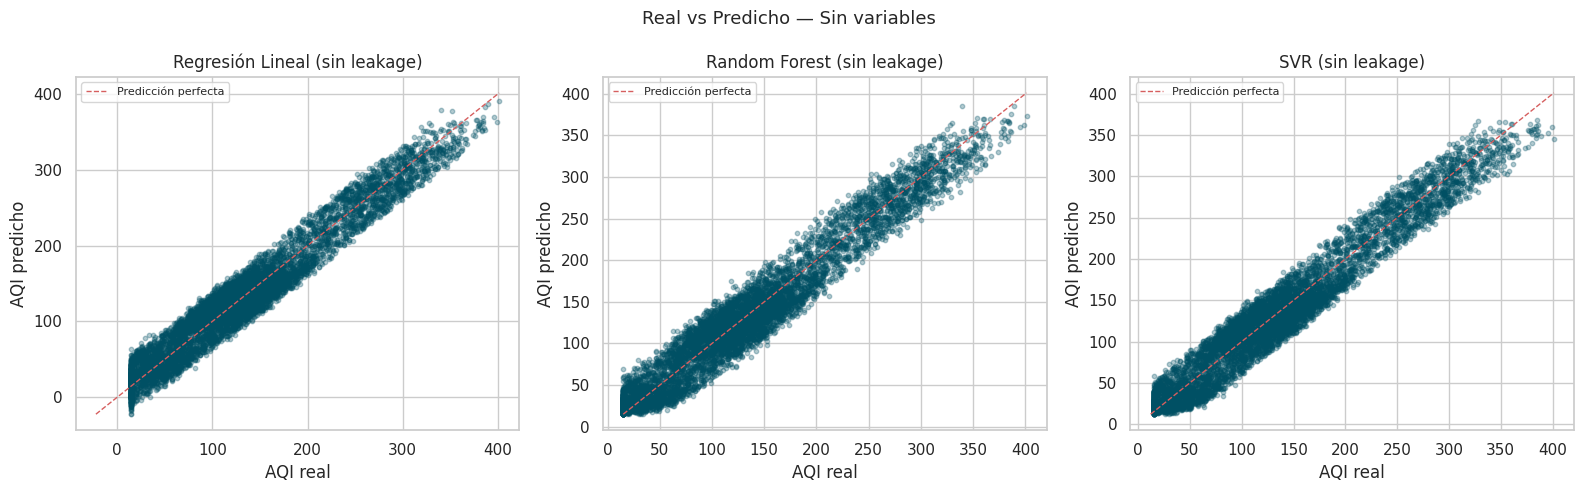

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, nombre in zip(axes, predicciones_bloque2.keys()):
    y_true, y_pred = predicciones_bloque2[nombre]
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='#005064')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Predicción perfecta')
    ax.set_xlabel('AQI real')
    ax.set_ylabel('AQI predicho')
    ax.set_title(nombre)
    ax.legend(fontsize=8)

plt.suptitle('Real vs Predicho — Sin variables ', fontsize=13)
plt.tight_layout()
plt.show()

### 5.6 Importancia de variables — Random Forest (sin 3 variables)

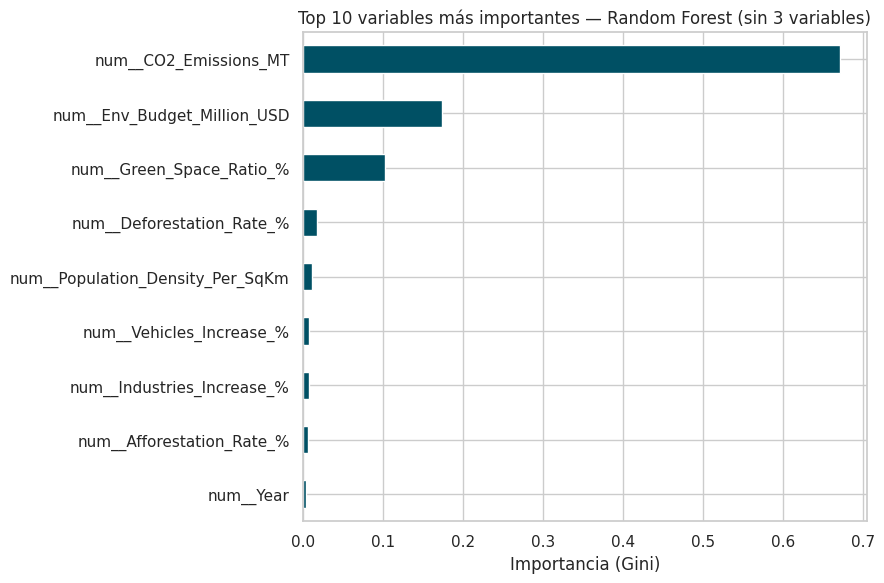

In [30]:
feature_names_clean = modelo_rf_clean.named_steps['preprocesamiento'].get_feature_names_out()
importancias_clean = pd.Series(
    modelo_rf_clean.named_steps['regresor'].feature_importances_,
    index=feature_names_clean
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importancias_clean.tail(10).plot(kind='barh', ax=ax, color='#005064', edgecolor='white')
ax.set_title('Top 10 variables más importantes — Random Forest (sin 3 variables)', fontsize=12)
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

---
## 6. Ajuste de hiperparámetros — Random Forest ('PM2.5', 'PM10', 'Avg_Life_Expectancy_Index')

Se prueban distintas combinaciones de hiperparámetros con validación cruzada de 5 folds
para encontrar la mejor configuración del Random Forest, usando el dataset **sin leakage**
(el escenario realista).

In [20]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regresor__n_estimators': [100, 200],
    'regresor__max_depth':    [None, 10, 20],
    'regresor__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    modelo_rf_clean,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_clean, y_train_clean)

print('Mejores hiperparámetros:', grid_search.best_params_)
print(f'Mejor RMSE (CV): {-grid_search.best_score_:.4f}')

best_rf_clean = grid_search.best_estimator_

y_pred_train_best = best_rf_clean.predict(X_train_clean)
y_pred_test_best  = best_rf_clean.predict(X_test_clean)

rmse_train_best = np.sqrt(mean_squared_error(y_train_clean, y_pred_train_best))
r2_train_best   = r2_score(y_train_clean, y_pred_train_best)
rmse_test_best  = np.sqrt(mean_squared_error(y_test_clean, y_pred_test_best))
r2_test_best    = r2_score(y_test_clean, y_pred_test_best)

print('\n=== Random Forest (mejor configuración, sin leakage) ===')
print(f'          RMSE       R²')
print(f'Train:    {rmse_train_best:.4f}    {r2_train_best:.4f}')
print(f'Test:     {rmse_test_best:.4f}    {r2_test_best:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros: {'regresor__max_depth': 20, 'regresor__min_samples_split': 5, 'regresor__n_estimators': 200}
Mejor RMSE (CV): 20.6810

=== Random Forest (mejor configuración, sin leakage) ===
          RMSE       R²
Train:    8.9730    0.9892
Test:     20.6778    0.9431
